<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter9/9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 순환 신경망으로 IMDB 리뷰 분류하기

## IMDB 리뷰 데이터셋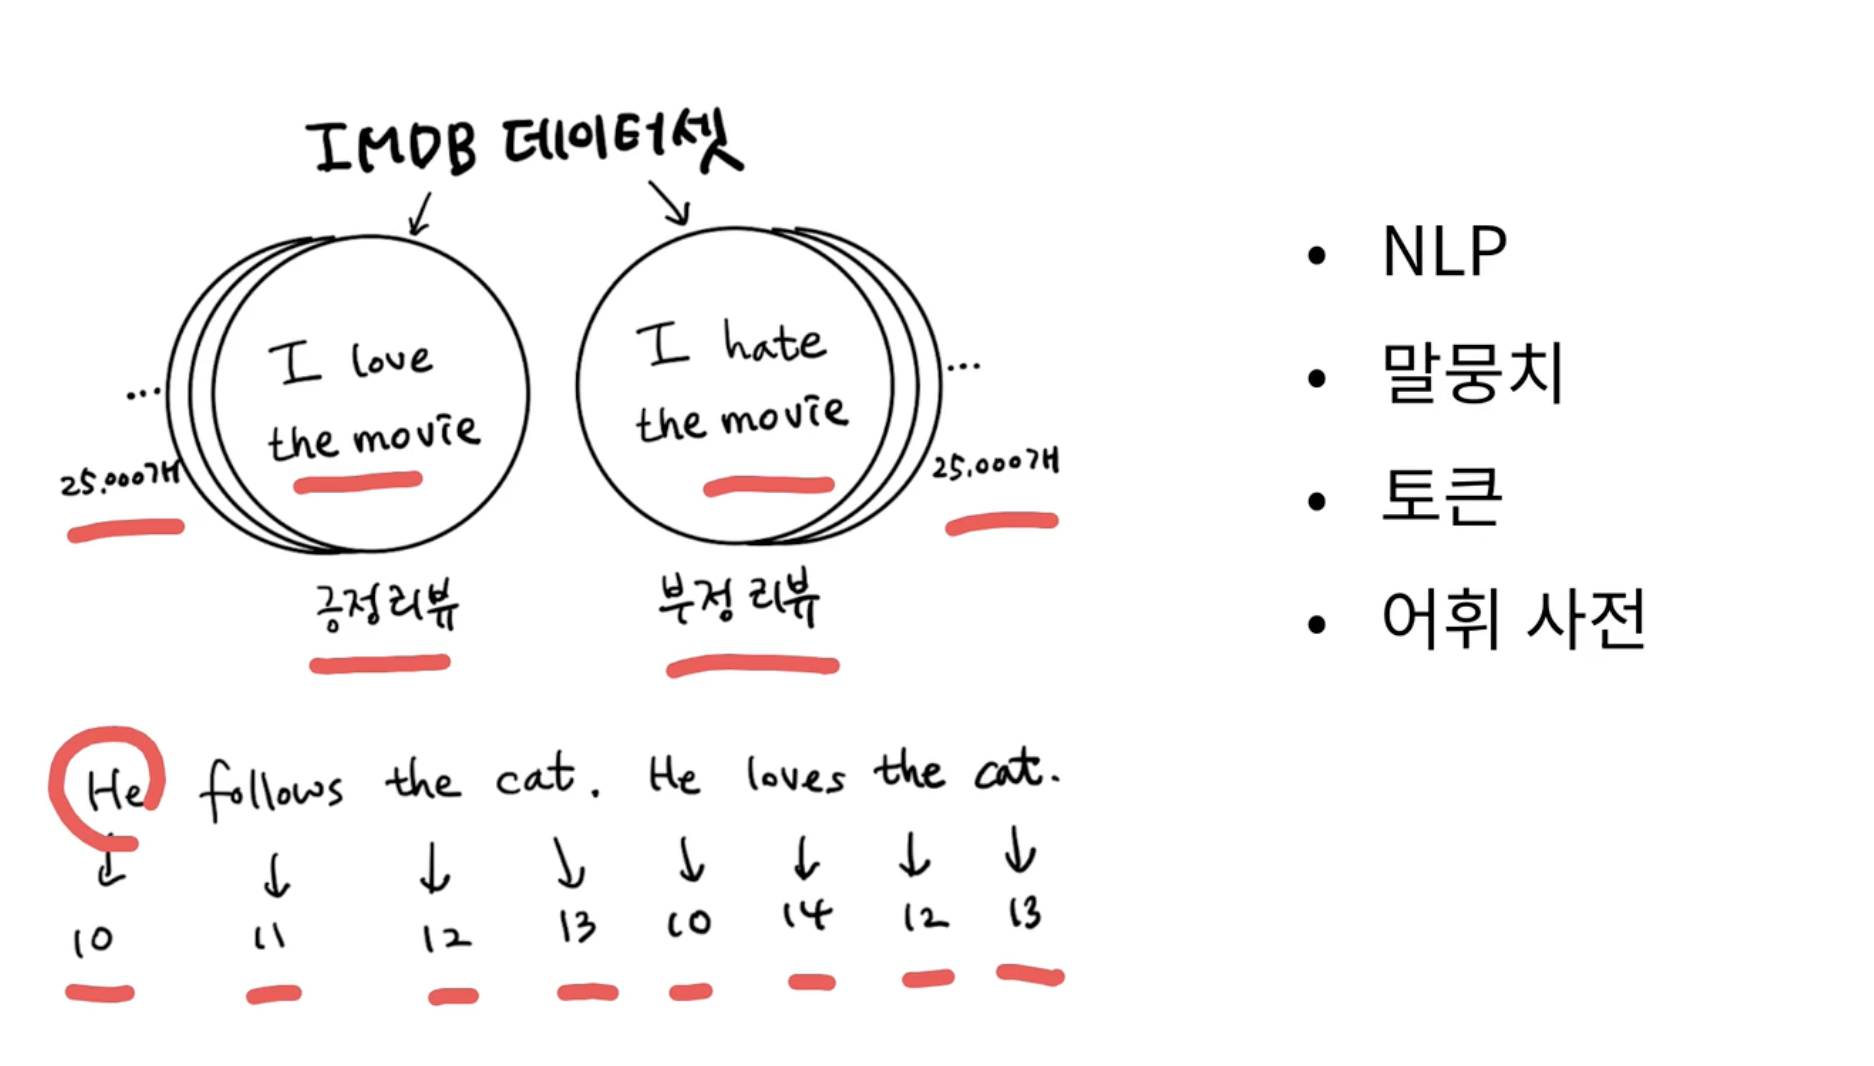

자연어 처리는 컴퓨터를 사용해 인간의 언어를 처리하는 분야

자연어 처리 분야에서는 훈련 데이터를 종종 말뭉치라고 부름

IMDB 리뷰 데이터 셋은 훈련데이터 테스트 데이터에 각각 25000개씩 나누어져있음

일반적으로 영어 문장은 모두 손문자로 바꾸고 구둣점을 삭제한 다음 공백을 기준으로 분리. 이렇게 분리된 단어를 토큰이라고 부른다

하나의 샘플은 여러 개의 토큰으로 이루어져 있고 1개의 토큰이 하나의 타임스텝에 해당

훈련 세트에서 고유한 단어를 뽑아 만든 목록을 어휘 사전이라고 한다

In [1]:
#IMDB 데이터 로드하기(이미 정수로 바꾼 데이터가 포함되어있음)
#자주 쓰는 단어 200개만 사용
from keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = \
imdb.load_data(num_words=200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
#크기 확인(1차원 배열인 이유는 리뷰 텍스트의 길이는 제각각인데 고정 크기의 2차원 배열에 담기 보다는 리뷰마다 별도의 파이썬 리스트로 담아야 메모리를 효율적으로 사용할 수 있기 때문)
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [3]:
#첫번째 리뷰 길이
print(len(train_input[0]))

218


In [4]:
#두번째 리뷰 길이
print(len(train_input[1]))

189


In [5]:
#첫번째 리뷰 내용(이미 정수로 변환되어 있고 어휘 사전에는 200개의 단어만 들어가 있기에 어휘 사전에 없는 단어는 모두 2로 표시)
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [6]:
#타깃데이터 출력(0은 부정, 1은 긍정인 이진분류로 볼 수 있다)
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [7]:
#검증세트 나누기
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [8]:
#각 리뷰의 길이를 계싼해 넘파이 배열에 담기(평균적인 리뷰의 길이와 가장 짧은 리뷰의 길이 그리고 가장 긴 리뷰의 길이를 확인하기 위해)
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [10]:
#평균과 중간값(한쪽으로 치우침)
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


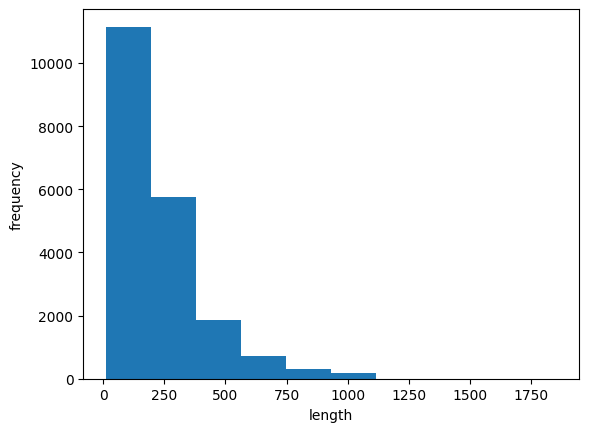

In [11]:
#히스토그램 표현
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()
#대부분의 리뷰 길이는 300미만. 평균이 중간값보다 높은 이유는 오른쪽 끝에 아주 큰 데이터가 있기 때문에

## 시퀀스 패딩
길이가 100 미만인 리뷰만 사용할 것인데 여전히 100개의 단어보다 작은 리뷰가 있다. 이런 리뷰들의 길이를 100에 맞추기 위해 패딩이 필요하다.

케라스는 시퀀스 데이터의 길이를 맞추는 함수를 제공한다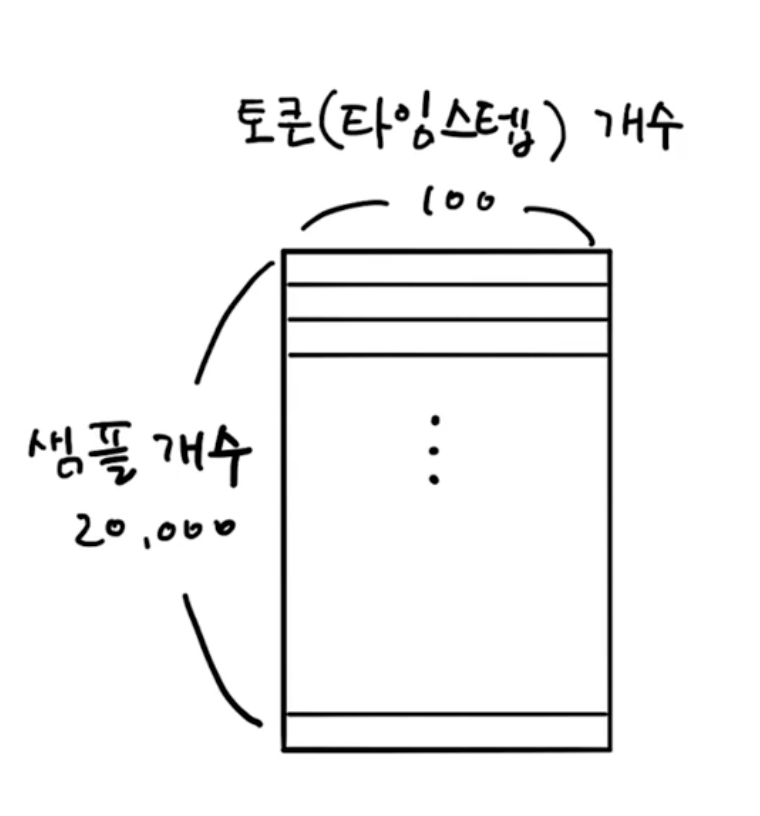

In [12]:
#시퀀스 패딩
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen = 100)

#크기 확인
print(train_seq.shape)

(20000, 100)


In [14]:
#첫번째 샘플 출력(0이 없는걸 보니 100보단 길었을 것)
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [15]:
#앞부분이 잘렸다는걸 확인(뒷 부분의 정보가 더 유용할 것이라 기대하기 때문)
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [16]:
#여섯번째 샘플 출력(앞 부분에 0이 있으므로 길이가 100이 안됐을 것)
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [17]:
#검증 세트의 길이도 100으로 맞추기
val_seq = pad_sequences(val_input, maxlen=100)

## 순환 신경망 만들기

In [18]:
#신경망 모델 만들기
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200))) #100은 샘플의 길이, 자주 등장하는 200개의 단어로 했기에 200
model.add(keras.layers.SimpleRNN(8)) #순환 신경망 클래스, 8은 사용할 뉴런의 개수, 활성화 함수는 기본적으로 tanh
model.add(keras.layers.Dense(1, activation='sigmoid'))  #

## 원-핫 인코딩
정수값에 크기 속성을 없애고 각 정수를 고유하게 표현하는 방법.

예를 들어 첫번째 샘플의 첫번째 토큰인 10을 원-핫 인코딩으로 표현하면 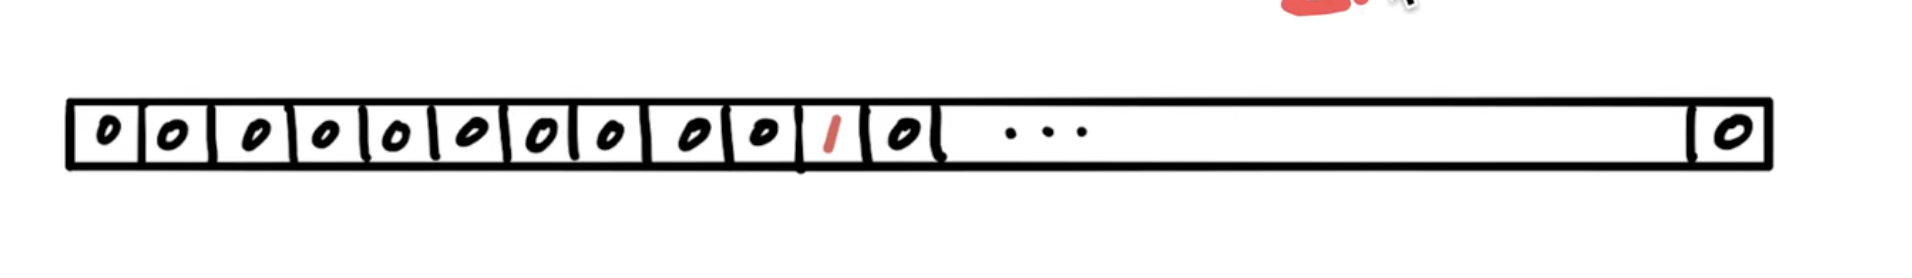

In [21]:
#함수 사용
train_oh = keras.utils.to_categorical(train_seq)

#크기 확인
print(train_oh.shape)
#정수 하나마다 200차원의 배열로 변경되었기 떄무에 (20000, 100) 에서 (20000, 100, 200)

(20000, 100, 200)


In [23]:
#첫번째 샘플의 첫 토큰 확인
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [24]:
#나머지 원소들이 0인지 확인
print(np.sum(train_oh[0][0]))

1.0


In [25]:
#검증세트도 원-핫 인코딩으로 바꾸기
val_oh = keras.utils.to_categorical(val_seq)

In [26]:
#앞서 만든 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

## 순환 신경망 모델 훈련
훈련 방법은 앞 장에서 했던것과 유사.

이진분류이기때문에 loss에 binary_crossentropy 사용

In [28]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5149 - loss: 0.6945 - val_accuracy: 0.5202 - val_loss: 0.6906
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5378 - loss: 0.6881 - val_accuracy: 0.5350 - val_loss: 0.6864
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5616 - loss: 0.6811 - val_accuracy: 0.5488 - val_loss: 0.6807
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6356 - loss: 0.6396 - val_accuracy: 0.6894 - val_loss: 0.6008
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6970 - loss: 0.5848 - val_accuracy: 0.7032 - val_loss: 0.5795
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7044 - loss: 0.5745 - val_accuracy: 0.7162 - val_loss: 0.5661
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7188 - loss: 0.5626 - val_accuracy: 0.7104 - val_loss: 0.5784
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7240 - loss: 0.5536 

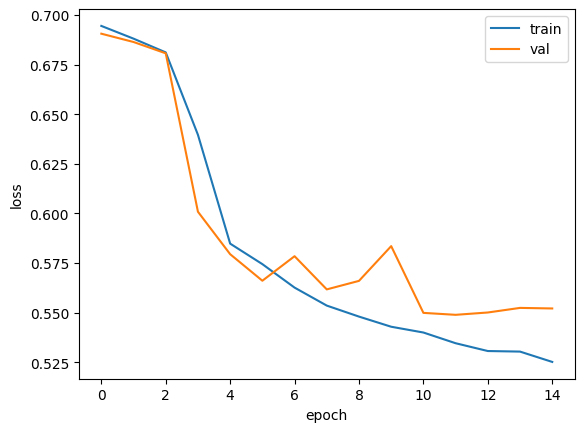

In [29]:
#훈련손실과 검증손실 그래프
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [30]:
#원핫 인코딩의 단점은 입력 데이터가 엄청 커진다는 것
print(train_seq.nbytes, train_oh.nbytes)

8000000 3200000000


## 임베딩
메모리를 많이 차지하는 원-핫인코딩보다 순환 신경망에 사용하는 더 좋은 단어 표현 방법 알아보기

단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 바꾸어준다.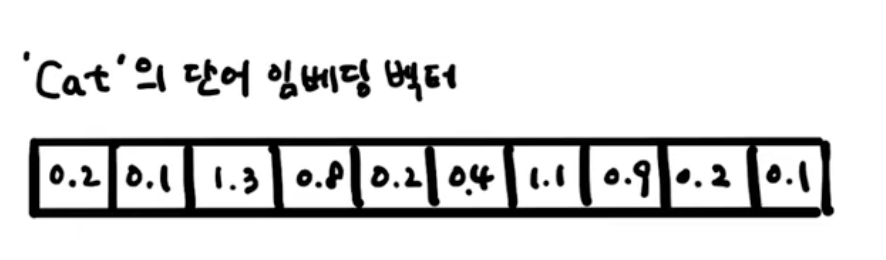

In [31]:
#효율적인 방법을 쓰기에 단어를 200개가 아닌 500개로 늘릴수 있음
#데이터 가져오기
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)

#검증 세트 나누기
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [32]:
#시퀀스 함수를 써서 패딩 및 길이를 100으로 제한
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [33]:
#임베딩 클래스를 순환층 앞에 추가한 두 번째 순환 신경망 만들기
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,))) #train_seq을 그대로 사용할 예정이기에 (100,)
model_emb.add(keras.layers.Embedding(500, 16)) #임베딩, 500은 어휘사전의 크기, 16은 임베딩 벡터의 크기
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [35]:
#모델 요약
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

임베딩 층은 (100,) 크기의 입력을 받아 (100,16)크기의 출력을 만듦.

임베딩 클래스는 200개의 각 토큰을 크기가 16인 벡터로 변경하기 때문에 3200개의 모델 파라미터를 가진다.

순환 신경망층은 임베딩 벡터의 크기각 16이므로 8개의 뉴런과 곱하기 위해 가중치 128개를 가짐.

또한 은닉 상태에 곱해지는 가중치 64개 존재.

또한 절편 8개까지 해서 총 200개의 파라미터가 순환층에 존재

밀집층의 가중치의 개수는 동일하게 9개

In [39]:
#모델 훈련
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6328 - loss: 0.6377 - val_accuracy: 0.7006 - val_loss: 0.5857
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.7472 - loss: 0.5270 - val_accuracy: 0.7544 - val_loss: 0.5130
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7610 - loss: 0.5054 - val_accuracy: 0.7706 - val_loss: 0.4943
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7795 - loss: 0.4760 - val_accuracy: 0.7726 - val_loss: 0.4903
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7972 - loss: 0.4498 - val_accuracy: 0.7546 - val_loss: 0.5171
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8077 - loss: 0.4312 - val_accuracy: 0.7654 - val_loss: 0.4922
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8173 - loss: 0.4160 - val_accuracy: 0.7900 - val_loss: 0.4860
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8249 - loss: 0.4024

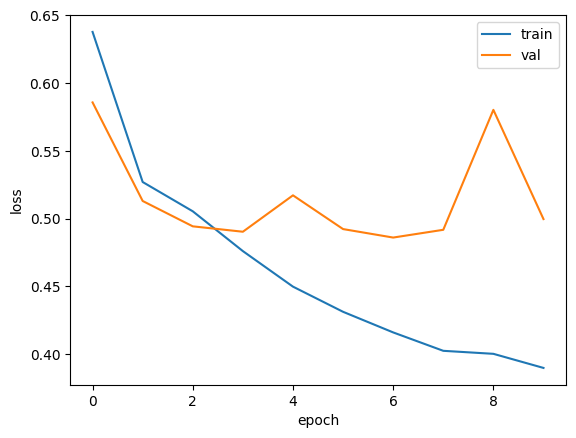

In [40]:
#훈련손실과 검증손실 그래프
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()